In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import os
from tqdm import tqdm


In [ ]:
len(os.listdir("Rice\Arborio"))


500

In [ ]:
len(os.listdir("Rice\Basmati"))


500

In [ ]:
len(os.listdir("Rice\Karacadag"))


500

In [ ]:
DataPath = pathlib.Path("Rice")
all_paths = DataPath.glob("*/*.jpg")
all_paths


<generator object Path.glob at 0x000001F636BAF9A0>

In [15]:
all_paths = list(all_paths)
all_paths[:10]


[WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (1).jpg'),
 WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (10).jpg'),
 WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (100).jpg'),
 WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (101).jpg'),
 WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (102).jpg'),
 WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (103).jpg'),
 WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (104).jpg'),
 WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (105).jpg'),
 WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (106).jpg'),
 WindowsPath('C:/Users/Livia/Desktop/FCIM/IA/Rice/Arborio/Arborio (107).jpg')]

In [17]:
all_paths = list(map(lambda x : str(x), all_paths))
all_paths[:10]

['C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (1).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (10).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (100).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (101).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (102).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (103).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (104).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (105).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (106).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (107).jpg']

In [19]:
from random import shuffle

shuffle(all_paths)
all_paths[:10]

['C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (460).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (350).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (244).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (293).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (260).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (386).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Karacadag\\Karacadag (179).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (459).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (82).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (34).jpg']

In [21]:
def TestImageQuality(all_paths):
    new_all_paths = []
    for path in tqdm(all_paths):
        try :
            image = tf.io.read_file(path)
            image = tf.io.decode_jpeg(image, channels = 3)
        except : 
            continue
        new_all_paths.append(path)
    return new_all_paths

all_paths = TestImageQuality(all_paths)
all_paths[:10]

100%|██████████| 1500/1500 [00:01<00:00, 1111.16it/s]


['C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (460).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (350).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (244).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (293).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (260).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (386).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Karacadag\\Karacadag (179).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (459).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (82).jpg',
 'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (34).jpg']

In [23]:
# Getting their respective labels
def get_label(image_path):
    return image_path.split("\\")[-2]
    # Change to -3 to get the weather condition (e.g., "Rainy" or "Sunny")


all_labels = list(map(lambda x : get_label(x), all_paths))
all_labels[:10]

['Arborio',
 'Basmati',
 'Arborio',
 'Basmati',
 'Arborio',
 'Basmati',
 'Karacadag',
 'Basmati',
 'Arborio',
 'Basmati']

In [25]:
from sklearn.preprocessing import LabelEncoder

Le = LabelEncoder()
all_labels = Le.fit_transform(all_labels)

all_labels[:10]

array([0, 1, 0, 1, 0, 1, 2, 1, 0, 1], dtype=int64)

In [27]:
from sklearn.model_selection import train_test_split

Train_paths, Val_paths, Train_labels, Val_labels = train_test_split(all_paths, all_labels)


In [29]:
Train_paths[:10], Train_labels[:10]

(['C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (267).jpg',
  'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (297).jpg',
  'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (172).jpg',
  'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Karacadag\\Karacadag (285).jpg',
  'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Karacadag\\Karacadag (261).jpg',
  'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (221).jpg',
  'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Basmati\\basmati (171).jpg',
  'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Karacadag\\Karacadag (463).jpg',
  'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Arborio\\Arborio (293).jpg',
  'C:\\Users\\Livia\\Desktop\\FCIM\\IA\\Rice\\Karacadag\\Karacadag (265).jpg'],
 array([0, 0, 0, 2, 2, 1, 1, 2, 0, 2], dtype=int64))

In [31]:
# Function used to decide jpeg into Tensor

def load(image, label):
    image = tf.io.read_file(image)
    image = tf.io.decode_jpeg(image, channels = 3)
    return image, label

In [33]:
import tensorflow as tf

IMG_SIZE = 224  # Example image size
BATCH_SIZE = 128

# Basic Transformation
resize = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMG_SIZE, IMG_SIZE)
])

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(height_factor=(0.2))
])


In [35]:
# Function used to Create a Tensorflow Data Object
AUTOTUNE = tf.data.experimental.AUTOTUNE
def get_dataset(paths, labels, train = True):
    image_paths = tf.convert_to_tensor(paths)
    labels = tf.convert_to_tensor(labels)

    image_dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    label_dataset = tf.data.Dataset.from_tensor_slices(labels)

    dataset = tf.data.Dataset.zip((image_dataset, label_dataset))

    dataset = dataset.map(lambda image, label : load(image, label))
    dataset = dataset.map(lambda image, label : (resize(image), label), num_parallel_calls=AUTOTUNE)
    dataset = dataset.shuffle(1000)
    dataset = dataset.batch(BATCH_SIZE)

    if train:
        dataset = dataset.map(lambda image, label: (data_augmentation(image), label), num_parallel_calls = AUTOTUNE)
        dataset = dataset.repeat()
    return dataset

In [37]:
# Creatinf Train Dataset object and Verifying it
# === Creare dataseturi ===
train_dataset = get_dataset(Train_paths, Train_labels, train=True)


#%time train_dataset = get_dataset(Train_paths, Train_labels)

image, label = next(iter(train_dataset))
print(image.shape)
print(label.shape)


(128, 224, 224, 3)
(128,)


Basmati


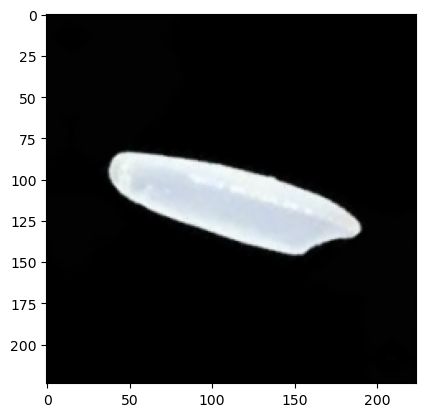

In [39]:
# View a sample Traininf Image
print(Le.inverse_transform(label)[0])
plt.imshow((image[0].numpy()/255).reshape(224, 224,  3))

In [41]:
#%time val_dataset = get_dataset(Val_paths, Val_labels, train = False)
val_dataset = get_dataset(Val_paths, Val_labels, train=False)
image, label = next(iter(val_dataset))
print(image.shape)
print(label.shape)

(128, 224, 224, 3)
(128,)


Arborio


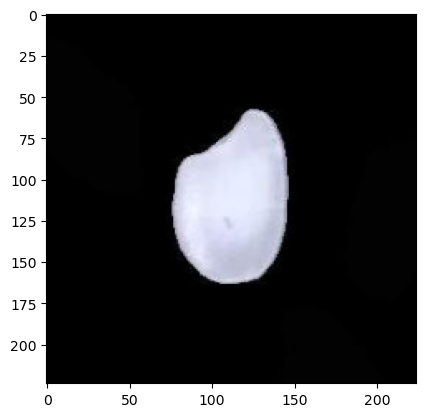

In [43]:
# View a sample Traininf Image
print(Le.inverse_transform(label)[1])
plt.imshow((image[0].numpy()/255).reshape(224, 224,  3))

Karacadag


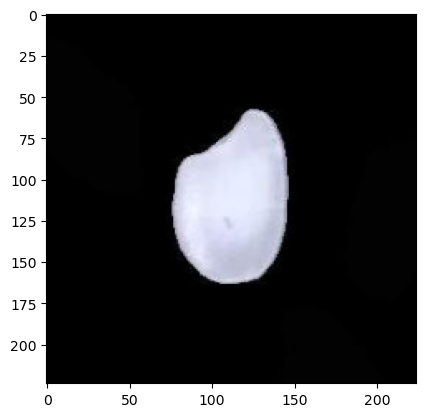

In [45]:
# View a sample Traininf Image
print(Le.inverse_transform(label)[0])
plt.imshow((image[0].numpy()/255).reshape(224, 224,  3))

In [47]:
# === Model CNN ===
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, GlobalMaxPool2D, Input, Activation

num_classes = len(np.unique(all_labels))

model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(16, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),

    Conv2D(16, (5,5), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),

    Conv2D(128, (3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),

    Conv2D(256, (3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),

    GlobalMaxPool2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

In [49]:
print(model.summary())



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 16)   │         6,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 108, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           77

 Total params: 979,923 (3.74 MB)

 Trainable params: 978,579 (3.73 MB)

 Non-trainable params: 1,344 (5.25 KB)

None


In [51]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # Am redus learning rate-ul
model.compile(
    loss='sparse_categorical_crossentropy',  
    optimizer=optimizer,
    metrics=['accuracy']
)


In [53]:
history = model.fit(
    train_dataset,
    steps_per_epoch=len(Train_paths) // BATCH_SIZE,
    validation_data=val_dataset,
    validation_steps=len(Val_paths) // BATCH_SIZE,
    epochs=15,
)
#https://www.kaggle.com/datasets/vishesh1412/celebrity-face-image-dataset

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.3537 - loss: 8.6591 - val_accuracy: 0.3594 - val_loss: 2.7737
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.4946 - loss: 2.0628 - val_accuracy: 0.3477 - val_loss: 5.2960
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.5304 - loss: 1.1885 - val_accuracy: 0.3867 - val_loss: 7.7993
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5629 - loss: 0.9776 - val_accuracy: 0.3750 - val_loss: 8.0548
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.6129 - loss: 0.7238 - val_accuracy: 0.3555 - val_loss: 8.5395
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.6536 - loss: 0.6720 - val_accuracy: 0.3711 - val_loss: 7.4272
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7016 - loss: 0.5867 - val_accuracy: 0.3711 - val_loss: 5.2102
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.7169 - loss: 0.5340 - val_accuracy: 0.3750 - val_loss: 4.5271
Epoch 9/

In [58]:
# Evaluating the Loaded model
loss, acc = model.evaluate(val_dataset)

print(" Testing Acc : ", acc)
print(" Testing Loss : ", loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 715ms/step - accuracy: 0.9150 - loss: 0.3274
 Testing Acc :  0.9120000004768372
 Testing Loss :  0.3273765444755554


In [99]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import tensorflow as tf

def plot(history, test_dataset, model, class_names):
    # 1. Plot Accuracy & Loss
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax = ax.ravel()

    for i, met in enumerate(['accuracy', 'loss']):
        ax[i].plot(history.history[met])
        ax[i].plot(history.history['val_' + met])
        ax[i].set_title(f'Model {met}')
        ax[i].set_xlabel('Epochs')
        ax[i].set_ylabel(met.capitalize())
        ax[i].legend(['Train', 'Validation'])

    # 2. Predict on test dataset
    y_true = []
    y_pred = []

    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy().tolist())  

    # 3. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # 5. Display some test images with predictions
    plt.figure(figsize=(12, 8))
    for images, labels in test_dataset.take(1):
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)
        true_labels = labels.numpy().tolist()

        for i in range(min(12, len(images))):
            plt.subplot(4, 3, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.axis("off")
            plt.title(f"True: {class_names[true_labels[i]]}\nPred: {class_names[preds[i]]}")

    plt.tight_layout()
    plt.show()

    return history


In [101]:
class_names = ['Arborio', 'Basmati', 'Karacadag']  



Classification Report:
              precision    recall  f1-score   support

     Arborio       0.99      0.72      0.83       107
     Basmati       0.86      1.00      0.92       133
   Karacadag       0.93      0.98      0.95       135

    accuracy                           0.91       375
   macro avg       0.92      0.90      0.90       375
weighted avg       0.92      0.91      0.91       375



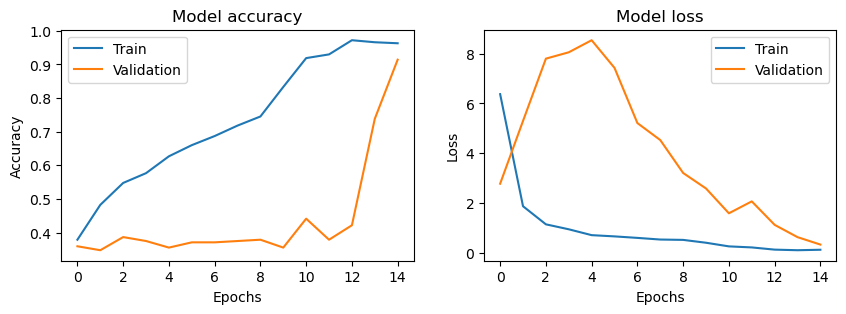

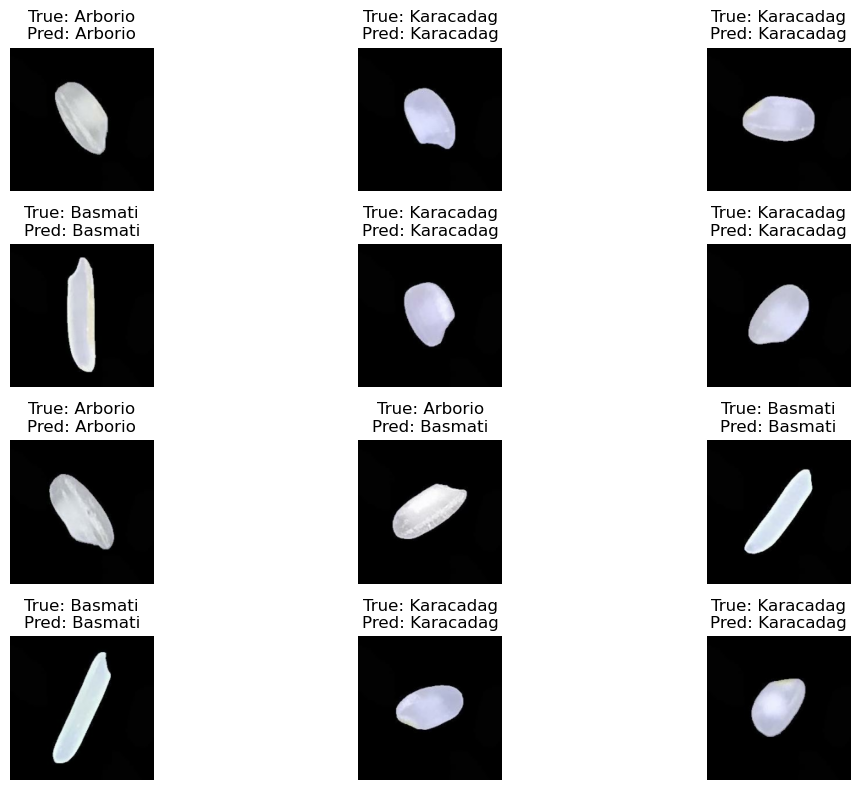

In [103]:
history_ResNet = plot(history, val_dataset, model, class_names)
